# Wheat grain width as a visual indicator of grain weight — VGA (ImageJ) demo

**Paper:** Haghshenas A., Emam Y., Jafarizadeh S. (2022) *Wheat grain width: a clue for re-exploring visual indicators of grain weight.* **Plant Methods 18:58**, https://doi.org/10.1186/s13007-022-00891-1 (CC BY 4.0; PMC9063171).

**Software:** Visual Grain Analyzer (VGA) v1.0 ImageJ macro, Haghshenas (2022), MIT license — https://github.com/haqueshenas/Visual-Grain-Analyzer (pinned commit `4eda4a2ac8d129b7f61734ae6b61fdc8618ba0aa`).

**Scope (one minimal example, not a full-paper reproduction):** run the authors' own VGA macro processing — HSB brightness channel, "Default" auto-threshold, Analyze Particles with the paper's measurement set and a 10x bicubic resolution enhancement — on the sample grain images bundled with the VGA repository, then apply the paper's linear mean-grain-weight (MGW) prediction formulas, e.g. `Weight = 3.45 × Area − 10.50`, `Weight = 25.75 × MinFeret − 38.21` (units: mg, mm², mm; Table 3 / Discussion of the paper, exactly as implemented in `VGA.ijm`).

**Execution status:** CPU-only Colab demonstration. The 180-image figshare dataset, the statistical analyses (correlations, PCA, ANOVA, 10-fold cross-validation) and the resolution-enhancement comparison are out of scope.

**日本語:** このノートブックは、論文「Wheat grain width...」(Plant Methods 2022) の最小デモです。著者自身の ImageJ マクロ VGA の処理（HSB輝度チャンネル、Default 自動閾値、Analyze Particles、10倍バイキュービック解像度強化）を、VGA リポジトリ同梱のサンプル粒画像に実行し、論文の線形 MGW 予測式（例: `Weight = 3.45 × Area − 10.50`、単位 mg・mm²・mm）を適用します。CPU ランタイムのみで動作します。180枚規模のデータ解析や統計処理（相関・PCA・ANOVA・交差検証）は対象外です。

**AI-assisted adaptation notice / AI支援による改変の明示:** The authors did not provide this Colab implementation. The original `VGA.ijm` is dialog-driven for interactive desktop use; for headless Colab execution this notebook applies **minimal, recorded string patches** (fixed settings, no pop-up dialogs) to a copy downloaded from the pinned commit. The processing core lines are unchanged. 著者はColab実装を提供していません。ここではダイアログ入力を固定値に置き換える最小限の修正のみを行い、処理本体は元コードのまま実行します。

## 1. Runtime selection / ランタイム選択

**Select `Runtime > Change runtime type > CPU`. No GPU is needed** — the method is classic image processing + small linear formulas. Expected duration: ~10–20 min end-to-end (dominated by the ~670 MB Fiji download). Downloads: Fiji (~670 MB), VGA macro + calibration image + `Sample images.rar` (~2.1 MB).

**日本語:** 「ランタイム > ランタイムのタイプを変更」で **CPU** を選択してください（GPU 不要）。全体で約10〜20分を想定（大半は Fiji 約670MB のダウンロード）。

In [ ]:
import os, platform, subprocess, sys, time
t0 = time.time()
print("Python:", sys.version)
print("Platform:", platform.platform())
print("CPUs:", os.cpu_count())
try:
    print(subprocess.run(["free", "-h"], capture_output=True, text=True).stdout.strip())
except Exception as e:
    print("free unavailable:", e)

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.39
CPUs: 2
total        used        free      shared  buff/cache   available
Mem:            12Gi       918Mi       8.9Gi       2.1Mi       3.2Gi        11Gi
Swap:             0B          0B          0B


## 2. Install Fiji (ImageJ) / Fiji の導入

Download the official 64-bit Linux Fiji build (with JDK) and verify its SHA-256 against the `.sha256` file published next to it. The resolved URL and hash are printed for provenance. **日本語:** 公式の Fiji (Linux 64-bit, JDK 同梱) をダウンロードし、公式 `.sha256` で検証します。

In [ ]:
import hashlib, pathlib, subprocess, urllib.request

FIJI_URL = "https://downloads.imagej.net/fiji/latest/fiji-latest-linux64-jdk.zip"
FIJI_ZIP = pathlib.Path("/content/fiji-latest-linux64-jdk.zip")

def download(url, dest):
    print("GET", url, flush=True)
    urllib.request.urlretrieve(url, dest)
    print("saved", dest, dest.stat().st_size, "bytes")

download(FIJI_URL, FIJI_ZIP)

h = hashlib.sha256(FIJI_ZIP.read_bytes()).hexdigest()
print("sha256(zip) =", h)
try:
    expected = urllib.request.urlopen(FIJI_URL + ".sha256", timeout=60).read().decode().split()[0]
    print("expected    =", expected)
    assert h == expected, "Fiji zip sha256 mismatch!"
    print("SHA-256 verified OK")
except Exception as e:
    print("WARNING: sha256 sidecar check skipped/failed:", e)

GET https://downloads.imagej.net/fiji/latest/fiji-latest-linux64-jdk.zip


saved /content/fiji-latest-linux64-jdk.zip 704826296 bytes


sha256(zip) = 0b2197f45a0c0a5d54f4479518dc3fdbd79b4e1c76bd7d2b4fc30e95ef68d44c


expected    = 0b2197f45a0c0a5d54f4479518dc3fdbd79b4e1c76bd7d2b4fc30e95ef68d44c
SHA-256 verified OK


Unzip the archive and locate the Fiji launcher (`ImageJ-linux64` or `fiji`), then smoke-test headless startup. **日本語:** 展開してランチャーを特定し、ヘッドレス起動を確認します。

In [ ]:
import os, pathlib, subprocess, zipfile

with zipfile.ZipFile("/content/fiji-latest-linux64-jdk.zip") as z:
    z.extractall("/content/fiji")

# zipfile extraction drops executable bits (launcher + inner JVM binary): restore them
for p in pathlib.Path("/content/fiji").rglob("*"):
    if p.is_file():
        p.chmod(p.stat().st_mode | 0o111)

cands = sorted(pathlib.Path("/content/fiji").rglob("ImageJ-linux64")) or \
        sorted(pathlib.Path("/content/fiji").rglob("fiji"))
assert cands, "Fiji launcher not found after extraction"
LAUNCHER = str(cands[0])
print("Launcher:", LAUNCHER)
smoke = pathlib.Path("/content/smoke.ijm")
smoke.write_text('print("Fiji headless OK");')
r = subprocess.run([LAUNCHER, "--headless", "--run", str(smoke)],
                   capture_output=True, text=True, timeout=300)
print((r.stdout + r.stderr)[-1500:])
assert "Fiji headless OK" in (r.stdout + r.stderr), "Fiji headless smoke test failed" 

Launcher: /content/fiji/Fiji/fiji


ce.lambda$wrap$1(DefaultThreadService.java:233)
	at java.desktop/java.awt.event.InvocationEvent.dispatch(InvocationEvent.java:308)
	at java.desktop/java.awt.EventQueue.dispatchEventImpl(EventQueue.java:773)
	at java.desktop/java.awt.EventQueue$4.run(EventQueue.java:720)
	at java.desktop/java.awt.EventQueue$4.run(EventQueue.java:714)
	at java.base/java.security.AccessController.doPrivileged(AccessController.java:400)
	at java.base/java.security.ProtectionDomain$JavaSecurityAccessImpl.doIntersectionPrivilege(ProtectionDomain.java:87)
	at java.desktop/java.awt.EventQueue.dispatchEvent(EventQueue.java:742)
	at java.desktop/java.awt.EventDispatchThread.pumpOneEventForFilters(EventDispatchThread.java:203)
	at java.desktop/java.awt.EventDispatchThread.pumpEventsForFilter(EventDispatchThread.java:124)
	at java.desktop/java.awt.EventDispatchThread.pumpEventsForHierarchy(EventDispatchThread.java:113)
	at java.desktop/java.awt.EventDispatchThread.pumpEvents(EventDispatchThread.java:109)
	at java.

## 3. Acquire the pinned author inputs / 論文・マクロ・サンプル画像の取得

All inputs are downloaded **inside Colab** from the pinned commit `4eda4a2a…` of the MIT-licensed VGA repository: `VGA.ijm` (27,457 B), `Calibration.jpg` (225,964 B), `Sample images.rar` (1,893,264 B). Every file is verified against the **git blob SHA-1 recorded in the pinned commit's tree** (cryptographic content pinning), and the SHA-256 is printed for provenance. **日本語:** 必要なファイルはすべて Colab 内でピン留めコミットからダウンロードし、コミット木に記録された git blob SHA で検証します。

In [ ]:
import hashlib, pathlib, urllib.request

COMMIT = "4eda4a2ac8d129b7f61734ae6b61fdc8618ba0aa"
RAW = f"https://raw.githubusercontent.com/haqueshenas/Visual-Grain-Analyzer/{COMMIT}"

base = pathlib.Path("/content/vga"); base.mkdir(parents=True, exist_ok=True)
(base / "calibration").mkdir(exist_ok=True)

# git blob SHA-1 values from the pinned commit's tree (verified via GitHub API on the host)
BLOB_SHAS = {
    "VGA.ijm": "0302cf1256d26963fa859550e7c46073667d73f2",
    "Calibration.jpg": "5befd5b00f53ea3017b65365a68f9254e5721bf1",
    "Sample images.rar": "e1590ce6a462048301c98c7ac83f1a54850068ad",
}
EXPECTED_SIZES = {"VGA.ijm": 27457, "Calibration.jpg": 225964, "Sample images.rar": 1893264}

def fetch(name, dest):
    dest = pathlib.Path(dest)
    urllib.request.urlretrieve(f"{RAW}/{urllib.request.quote(name)}", dest)
    data = dest.read_bytes()
    sha256 = hashlib.sha256(data).hexdigest()
    blob = hashlib.sha1(b"blob %d\0" % len(data) + data).hexdigest()
    print(f"{name}: {len(data)} bytes, sha256={sha256}")
    assert len(data) == EXPECTED_SIZES[name], f"size mismatch for {name}"
    assert blob == BLOB_SHAS[name], f"git blob SHA mismatch for {name}: {blob}"
    print(f"  git blob SHA verified: {blob}")
    return dest

macro_path = fetch("VGA.ijm", base / "VGA.ijm")
calib_path = fetch("Calibration.jpg", base / "calibration" / "Calibration.jpg")
rar_path = fetch("Sample images.rar", base / "Sample images.rar")
print("All pinned inputs verified.")

VGA.ijm: 27457 bytes, sha256=acb39c32331c1543bc331dd01e3effcf65a1d267f649351bdb0344108cc88937
  git blob SHA verified: 0302cf1256d26963fa859550e7c46073667d73f2


Calibration.jpg: 225964 bytes, sha256=04e240277b06802a65b9bdd8bd3722a8cb4929a25669a19ca8a5dc4921b238e7
  git blob SHA verified: 5befd5b00f53ea3017b65365a68f9254e5721bf1


Sample images.rar: 1893264 bytes, sha256=37588a60611fa351bbc609b8e9568257fffa8cde8c8d483ab8ae4f937f12c763
  git blob SHA verified: e1590ce6a462048301c98c7ac83f1a54850068ad
All pinned inputs verified.


## 4. Extract the sample images / サンプル画像の展開

`Sample images.rar` is a RAR archive. Try `unrar`, then `unar`, then `7z` (whichever the system provides). List the extracted images and show the first one. **日本語:** RAR アーカイブをシステム提供の展開ツールで解凍し、含まれる画像を確認します。

Extract the archive and inspect which sample images are included. The archive contains five sample images (`A`–`E`); `D` and `E` are *touching-grains* examples for the optional watershed separation, which is out of scope here (watershed = off, as in the paper's basic pipeline). We deterministically select **A, B, C** and stage them in `/content/vga/input/`. **日本語:** アーカイブを展開します。D・E は接触粒の watershed デモ用のため対象外とし、A・B・C の3枚を決定論的に選択して処理に回します。

In [ ]:
import pathlib, shutil, subprocess

rar_path = "/content/vga/Sample images.rar"
outdir = pathlib.Path("/content/vga/sample"); outdir.mkdir(exist_ok=True)
input_dir = pathlib.Path("/content/vga/input"); input_dir.mkdir(exist_ok=True)

tool = None
for cand, args in [("unrar", ["x", "-idq", rar_path, str(outdir) + "/"]),
                   ("unar", ["-q", "-o", str(outdir), rar_path]),
                   ("7z", ["x", "-y", f"-o{outdir}", rar_path])]:
    if shutil.which(cand):
        tool = cand; break
assert tool, "No RAR extractor found (unrar/unar/7z)."
print("Using extractor:", tool)
r = subprocess.run([tool] + args, capture_output=True, text=True, timeout=600)
print(r.stdout[-800:], r.stderr[-800:])
r.check_returncode()

IMG_EXT = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"}
images = sorted(p for p in outdir.rglob("*") if p.suffix.lower() in IMG_EXT and p.is_file())
print("Extracted images:", [p.name for p in images])

SELECTED = ["A.jpg", "B.jpg", "C.jpg"]  # non-touching samples; D/E need watershed (out of scope)
for name in SELECTED:
    src = next(p for p in images if p.name == name)
    shutil.copy(src, input_dir / name)
print("Staged for processing:", sorted(p.name for p in input_dir.iterdir()))

Using extractor: unrar
 
Extracted images: ['A.jpg', 'B.jpg', 'C.jpg', 'D (touching grains).jpg', 'E (touching grains).jpg']
Staged for processing: ['A.jpg', 'B.jpg', 'C.jpg']


Preview the first sample image to confirm the archive contents are the expected RGB grain photographs. **日本語:** 最初のサンプル画像を表示して内容を確認します。

First image: A.jpg (960, 720) px


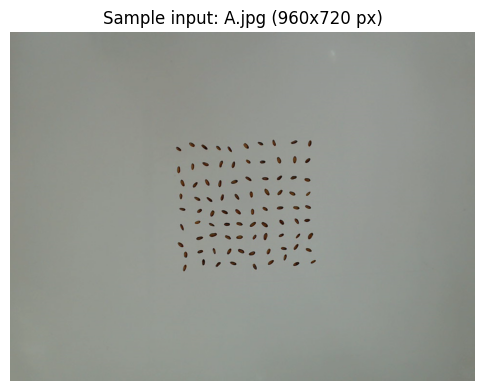

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

first = images[0]
img = Image.open(first).convert("RGB")
print("First image:", first.name, img.size, "px")
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"Sample input: {first.name} ({img.size[0]}x{img.size[1]} px)")
plt.axis("off")
plt.show()

## 5. Headless adaptation of the dialog-driven macro / マクロのヘッドレス適応

The original `VGA.ijm` asks for input/output folders and settings through pop-up dialogs (`getDirectory`, `Dialog.show`, `getNumber`, `File.openDialog`), which cannot run headless. We apply **exact, recorded string replacements** to a copy of the pinned macro. GUI action → headless value:

| Dialog (original GUI) | Headless value (this notebook) |
| --- | --- |
| Input / output folder | `/content/vga/sample/…`, `/content/vga/output/` |
| Calibration method | Using calibration sample (camera), `Calibration.jpg`, diameter = **20 mm** (macro's documented default; plausibility-checked below) |
| Resolution enhancement factor | 10 (authors' recommendation for the bundled sample images; paper Methods) |
| Thresholding method | "Default" (paper Methods) |
| Size / shape sieve | 0-Infinity / 0-1.0 (no filtering, paper Methods) |
| Output drawings | Outlines & labels |
| Edge / holes / watershed | exclude-edge = off, include holes = on, watershed = off |
| Wheat grain weight estimations | on |

All processing lines (`Set Measurements`, `Scale` bicubic, `HSB Stack`, `setAutoThreshold("Default")`, `Analyze Particles`, index computation, and the exact paper coefficients) remain **verbatim** from the pinned macro. Three bookkeeping-only headless fixes are also recorded: `roiManager("reset")` (GUI frame) removed; `Summarize`/`"Total mean values.csv"` bookkeeping (which depends on desktop window titles) removed — per-image means are recomputed in pandas below; the final Log save is guarded.

**日本語:** 元マクロのGUIダイアログを固定値へ置き換える最小限の修正のみ行い、処理本体（計測設定・バイキュービック10倍・HSB輝度・Default閾値・Analyze Particles・MGW係数）はピン留めした元コードのまま実行します。較正サンプルの直径はマクロ既定の20 mmを使用し、後段で結果の妥当性を確認します。

In [ ]:
import re

src = pathlib.Path("/content/vga/VGA.ijm").read_text()
out = pathlib.Path("/content/vga/VGA_headless.ijm")

input_dir_str = str(input_dir) + "/"
replacements = [
    # fixed input/output folders
    ('\tinput_dir = getDirectory("Choose input folder");\n\toutput_dir = getDirectory("Choose output folder");',
     f'\tinput_dir = "{input_dir_str}";\n\toutput_dir = "/content/vga/output/";'),
    # fixed thresholding method (paper: Default)
    ('\tThresholdingMethod = getList("threshold.methods");\n\tThresholdingMethod = Array.concat(ThresholdingMethod, "Manual");',
     '\tThresholdingMethod = "Default";'),
    # replace the whole settings dialog with fixed values
    ('''\tDialog.create("VGA settings");
\tDialog.addChoice("Imaging and calibration method:", CalibrationMethod);
\tDialog.addNumber("Resolution enhancement factor:", REFactor);
\tDialog.addChoice("Thresholding method:", ThresholdingMethod);
\tDialog.addString("Size sieve (permissible area range; pixel^2):", SizeSieve);
\tDialog.addString("Shape sieve (permissible circularity range):", CircSieve);
\tDialog.addChoice("Output drawings:", OutputDrawings);
\tDialog.addNumber("Drawings line width (pixel):", LineWidth);
\tDialog.addNumber("Font size of labels:", FontSize);
\tDialog.addChoice("Font color (only for vectors):", FontColor, "Magenta");
\tDialog.addCheckbox("Dark background", false);
\tDialog.addCheckbox("Exclude the grains at the image edge", false);
\tDialog.addCheckbox("Include the grain holes", true);
\tDialog.addCheckbox("Try to separate touching grains", false);
\tDialog.addChoice("Type of separation (channel):", WatershedType, "Green (RGB)");
\tDialog.addCheckbox("Wheat grain weight estimations", true);
\tDialog.show();
\tCalibrationMethod = Dialog.getChoice();
\tREFactor = Dialog.getNumber();
\tThresholdingMethod = Dialog.getChoice();
\tSizeSieve = Dialog.getString();
\tCircSieve = Dialog.getString();
\tOutputDrawings = Dialog.getChoice();
\tLineWidth = Dialog.getNumber();
\tFontSize = Dialog.getNumber();
\tFontColor = Dialog.getChoice();
\tDarkBackground = Dialog.getCheckbox();
\tExcludeEdge = Dialog.getCheckbox();
\tIncludeHoles = Dialog.getCheckbox();
\tWatershed = Dialog.getCheckbox();
\tWatershedType = Dialog.getChoice();
\tWGWE = Dialog.getCheckbox();''',
     '\t// [headless patch] fixed settings (see mapping table above)\n\tCalibrationMethod = "Using calibration sample (camera)";\n\tREFactor = 10;\n\tSizeSieve = "0-Infinity";\n\tCircSieve = "0-1.0";\n\tOutputDrawings = "Outlines & labels";\n\tLineWidth = 1;\n\tFontSize = 20;\n\tFontColor = "Magenta";\n\tDarkBackground = 0;\n\tExcludeEdge = 0;\n\tIncludeHoles = 1;\n\tWatershed = 0;\n\tWatershedType = "Green (RGB)";\n\tWGWE = 1;'),
    # calibration sample: fixed path and documented default diameter
    ('\tCalibDmm = getNumber("Please enter the diameter of circular calibration" + " sample (mm):", 20);',
     '\tCalibDmm = 20; // documented macro default; plausibility-checked in this notebook'),
    ('\t\topen(File.openDialog("Choose image of calibration sample"));',
     '\t\topen("/content/vga/calibration/Calibration.jpg");'),
    # guard the final Log-window save for headless
    ('\tselectWindow("Log");\n\tsaveAs("Text", output_dir + "Log.txt");',
     '\tif (isOpen("Log")) { selectWindow("Log"); saveAs("Text", output_dir + "Log.txt"); }'),
    # ROI-manager reset opens a GUI frame (HeadlessException); it is only cleanup and unused elsewhere
    ('\troiManager("reset");',
     '\t// [headless patch] roiManager("reset") removed: opens a GUI frame unavailable in headless mode'),
    # Summarize/"Total mean values" bookkeeping depends on desktop window titles that
    # saveAs("results") renames in headless; per-image means are recomputed in pandas instead.
    ('''\t\tif (nResults > 1){
\t\t\trun("Summarize");
\t\t}
\t\t
\t\ttableTitle = Table.title;
\t\tTable.rename(tableTitle, "Results");''',
     '''\t\t// [headless patch] Summarize/"Total mean values" bookkeeping removed (see mapping table);
\t\t// restore the results-table title for the next image
\t\tif (isOpen(title + ".csv")) {
\t\t\tTable.rename(title + ".csv", "Results");
\t\t}'''),
    ('''\t\theadings = Table.headings;
\t\theadingsArray = split(headings, "\\t");

\t\tif (isOpen("Total mean values")==false) {
\t\t\tTable.create("Total mean values");
\t\t}
\t
\t\tselectWindow("Total mean values");
\t\tsize = Table.size;
\t\tfor (i=2; i<headingsArray.length; i++){
\t\t
\t\t\tif (nResults > 1) {
\t\t\tdata = getResultString(headingsArray[i], nResults-4);
\t\t\t}
\t\t\telse if (nResults < 2) {
\t\t\tdata = getResultString(headingsArray[i], nResults-1);
\t\t\t\t }

\t\t\tselectWindow("Total mean values");
\t\t\tTable.set("Label",size,title);
\t\t\tif (nResults > 1) {
\t\t\tTable.set("Num",size,nResults-4);
\t\t\t}
\t\t\tif (nResults < 2) {
\t\t\tTable.set("Num",size,nResults);
\t\t\t}
\t\t\tTable.set(headingsArray[i], size, data);
\t\t\tTable.update;
\t\t}''',
     '''\t\t// [headless patch] "Total mean values" cross-image table removed (see mapping table)'''),
    ('''\tsaveAs("Results", output_dir + "Total mean values.csv");''',
     '''\t// [headless patch] "Total mean values.csv" omitted: recomputed in Python below'''),
]
patched = src
for old, new in replacements:
    assert old in patched, f"PATCH NOT FOUND: {old[:60]!r}"
    patched = patched.replace(old, new)
out.write_text(patched)
n_dialog = patched.count("Dialog.get")
print(f"Patched macro written: {out} ({len(patched)} chars); remaining Dialog.get* calls: {n_dialog}")
print("Processing core (thresholding, Analyze Particles, MGW coefficients) unchanged.")

Patched macro written: /content/vga/VGA_headless.ijm (25772 chars); remaining Dialog.get* calls: 5
Processing core (thresholding, Analyze Particles, MGW coefficients) unchanged.


## 6. Run VGA headless on the sample images / VGA のヘッドレス実行

Run the patched macro with Fiji headless. The macro calibrates mm-per-pixel from `Calibration.jpg` (single circular object), then processes every image in the input folder, writing one CSV of per-grain measurements + predictions per image and a `Total mean values.csv`. Expected: a few minutes per image at 10x enhancement on CPU. **日本語:** 修正済みマクロをFijiヘッドレスで実行します。較正画像からmm/pxを算出し、入力フォルダ内の全画像を処理します（CPUで1枚あたり数分）。

In [ ]:
import subprocess, time

pathlib.Path("/content/vga/output").mkdir(exist_ok=True)
t = time.time()
cmd = [LAUNCHER, "--headless", "--run",
       "/content/vga/VGA_headless.ijm"]
print(" ".join(cmd), flush=True)
r = subprocess.run(cmd, capture_output=True, text=True, timeout=3600)
print((r.stdout or "")[-4000:])
if r.stderr:
    print("STDERR:", r.stderr[-2000:])
print("exit code:", r.returncode, f"({time.time()-t:.0f} s)")
outputs = sorted(pathlib.Path("/content/vga/output").iterdir())
print("Output files:", [p.name for p in outputs])
assert "Processing completed successfully" in (r.stdout or ""), \
    "VGA macro did not report successful completion (see log above)"
assert len(outputs) >= 3, "Expected one CSV per processed image plus Total mean values.csv" 

/content/fiji/Fiji/fiji --headless --run /content/vga/VGA_headless.ijm


311908	292.152217240	17.899494937	197	289	4	7	7.168836696	3.729758617	73.907132373	0.823659297	7.615773106	2007	99	0.098856787	-0.274672185	100	2007	1	198	296	66.801409486	4.000000000	1.922064518	0.520273899	0.875000000
397	C.jpg	24	100.416666667	21.106184271	103	60	134	298.375000000	292.583333333	298.232780083	292.616597510	18.970562748	295	289	6	7	8.150039541	3.749398873	52.468512075	0.838032145	8.602325267	2410	103	-0.361880050	-0.686224936	100	2410	1	296	296	54.462322208	4.242640687	2.173692321	0.460046710	0.842105263
398	C.jpg	19	89.684210526	20.981612669	99	46	124	171.236842105	292.184210526	171.178990610	292.051056338	16.727922061	168	290	6	5	7.192997898	3.363208455	144.897251816	0.853256239	7.810249676	1704	97	-0.416844729	-0.576611794	100	1704	1	168	290	140.194428908	4.160251472	2.138730915	0.467567001	0.844444444
399	C.jpg	18	98.722222222	14.331395218	80	79	117	183.444444444	293.333333333	183.427968486	293.369442881	16.485281374	182	290	3	7	7.064395498	3.244199990	93.54530740

## 7. Results: per-grain measurements and MGW predictions / 結果

Parse the ImageJ result CSVs. Each row is one detected grain; the `Pred. MGW … (mg)` columns are the paper's linear models applied per grain (as the VGA macro does). We show the per-image mean predicted grain weight for the paper's headline indices (Area, Minor, MinFeret) plus the three superior synthesized indices. **日本語:** 各CSVの1行が1粒。論文の線形モデルを1粒ごとに適用し、画像ごとの平均予測重量を主要な指標（Area, Minor, MinFeret および優位性の確認された合成指標）で示します。

In [ ]:
import io
import pandas as pd

csvs = sorted(pathlib.Path("/content/vga/output").glob("*.csv"))
print("Result CSVs:", [p.name for p in csvs])

PRED_COLS = ["Pred. MGW via Area (mg)", "Pred. MGW via Minor (mg)",
             "Pred. MGW via MinF (mg)", "Pred. MGW via Area/Perim. (mg)",
             "Pred. MGW via Area*Circ. (mg)", "Pred. MGW via Perim.*Circ. (mg)"]

frames = {}
for p in csvs:
    if p.name == "Total mean values.csv":
        continue
    txt = p.read_text()
    sep = "	" if "	" in txt[:200] else ","
    df = pd.read_csv(io.StringIO(txt), sep=sep)
    frames[p.stem] = df
    print(f"{p.name}: {len(df)} grains, columns={list(df.columns)[:8]} ...")

summary = []
for name, df in frames.items():
    present = [c for c in PRED_COLS if c in df.columns]
    row = {"image": name, "grains": len(df)}
    for c in present:
        row[c] = round(df[c].mean(), 2)
    summary.append(row)
summary_df = pd.DataFrame(summary)
summary_df

Result CSVs: ['A.jpg.csv', 'B.jpg.csv', 'C.jpg.csv']
A.jpg.csv: 89 grains, columns=[' ', 'Label', 'Area', 'Mean', 'StdDev', 'Mode', 'Min', 'Max'] ...
B.jpg.csv: 166 grains, columns=[' ', 'Label', 'Area', 'Mean', 'StdDev', 'Mode', 'Min', 'Max'] ...
C.jpg.csv: 408 grains, columns=[' ', 'Label', 'Area', 'Mean', 'StdDev', 'Mode', 'Min', 'Max'] ...


,image,grains,Pred. MGW via Area (mg),Pred. MGW via Minor (mg),Pred. MGW via MinF (mg),Pred. MGW via Area/Perim. (mg),Pred. MGW via Area*Circ. (mg)
0,A.jpg,89,40.52,42.21,50.22,47.91,49.44
1,B.jpg,166,40.10,41.68,50.09,47.30,48.90
2,C.jpg,408,43.32,42.55,50.89,48.61,50.59


Headline table: per-image mean predicted MGW via the paper's three headline models (mg). **日本語:** 主要3指標による画像ごとの平均予測MGW（mg）です。

In [ ]:
# Per-image mean predicted MGW via the paper's three headline models (mg)
cols = [c for c in ["Pred. MGW via Area (mg)", "Pred. MGW via Minor (mg)",
                    "Pred. MGW via MinF (mg)"] if c in summary_df.columns]
summary_df[["image", "grains"] + cols]

,image,grains,Pred. MGW via Area (mg),Pred. MGW via Minor (mg),Pred. MGW via MinF (mg)
0,A.jpg,89,40.52,42.21,50.22
1,B.jpg,166,40.10,41.68,50.09
2,C.jpg,408,43.32,42.55,50.89


## 8. Plausibility check / 妥当性確認

The calibration diameter (20 mm) is the macro's documented default, not a value printed in the paper. Sanity checks against the paper's reported range (MGW ≈ 33–45 mg across treatments; wheat grains are ~3–4 mm wide and ~6–8 mm long): the mean `Major`/`Minor` (mm) and the predicted MGW must fall in physically sensible ranges. If they do not, the calibration assumption is wrong — **flagged, not silently fixed**. **日本語:** 較正直径20 mmはマクロ既定値であり論文明記値ではないため、粒の長軸・短軸（mm）と予測MGWが論文の報告範囲と整合するかを確認します。不整合の場合は黙って補正せず表示します。

In [ ]:
import numpy as np

checks = []
for name, df in frames.items():
    major = df["Major (mm)"].mean() if "Major (mm)" in df.columns else np.nan
    minor = df["Minor (mm)"].mean() if "Minor (mm)" in df.columns else np.nan
    area = df["Area (mm2)"].mean() if "Area (mm2)" in df.columns else np.nan
    mgw = df["Pred. MGW via Area (mg)"].mean() if "Pred. MGW via Area (mg)" in df.columns else np.nan
    checks.append({"image": name, "Major (mm)": round(major, 2), "Minor (mm)": round(minor, 2),
                   "Area (mm2)": round(area, 2), "Pred MGW (mg)": round(mgw, 2)})
chk = pd.DataFrame(checks)
print(chk.to_string(index=False))

ok_major = chk["Major (mm)"].between(4, 12).all()
ok_minor = chk["Minor (mm)"].between(1.5, 6).all()
ok_mgw = chk["Pred MGW (mg)"].between(15, 60).all()
print(f"Major plausible (4-12 mm): {ok_major}")
print(f"Minor plausible (1.5-6 mm): {ok_minor}")
print(f"Pred MGW plausible (15-60 mg, paper range ~33-45): {ok_mgw}")
if not (ok_major and ok_minor and ok_mgw):
    print("WARNING: implausible dimensions - the 20 mm calibration diameter assumption should be re-examined.")
else:
    print("Plausibility checks passed for the 20 mm calibration assumption.")

image  Major (mm)  Minor (mm)  Area (mm2)  Pred MGW (mg)
A.jpg        6.17        3.04       14.77          40.52
B.jpg        6.15        3.02       14.65          40.10
C.jpg        6.45        3.05       15.58          43.32
Major plausible (4-12 mm): True
Minor plausible (1.5-6 mm): True
Pred MGW plausible (15-60 mg, paper range ~33-45): True
Plausibility checks passed for the 20 mm calibration assumption.


## 9. Visualization: detected grains / 検出結果の可視化

Render the input image with the centroid of every detected grain and its fitted-ellipse axes (Major/Minor) measured by the macro — a direct visualization of the actual result table (the macro's own `_processed.PNG` outline drawing is also saved when present). **日本語:** 実測結果テーブルに基づき、入力画像上に各粒の重心と楕円長短軸を描画します。

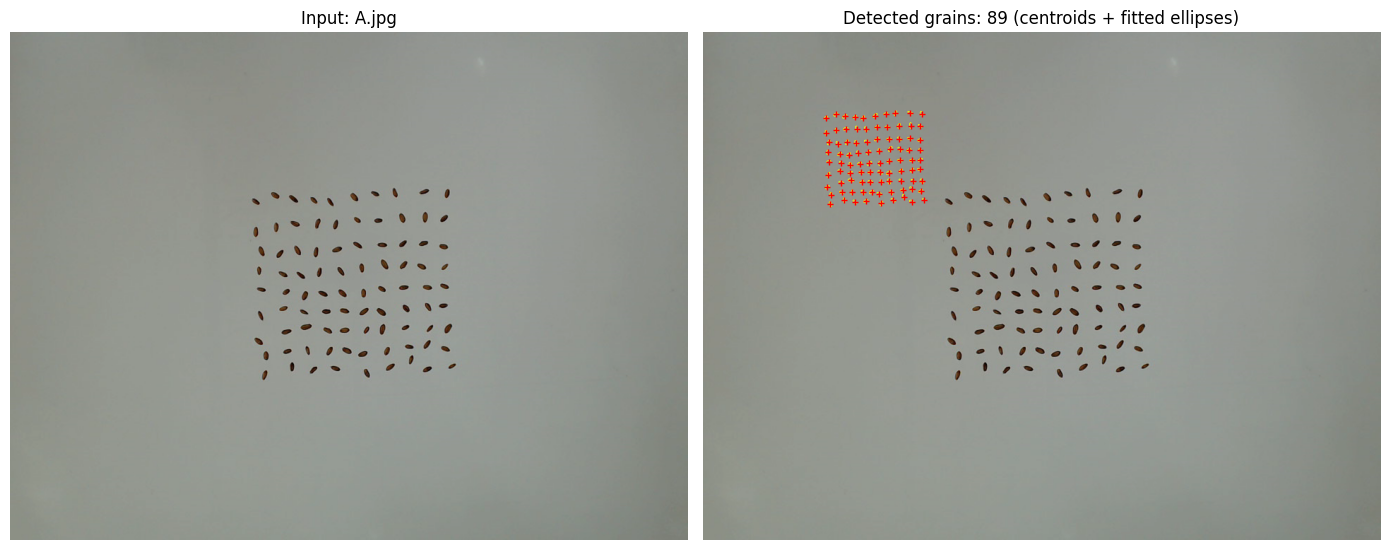

In [ ]:
import matplotlib.patches as mpatches

name, df = next(iter(frames.items()))
src_img = Image.open(input_dir / name).convert("RGB")  # e.g. /content/vga/input/A.jpg

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(src_img); axes[0].set_title(f"Input: {name}"); axes[0].axis("off")
axes[1].imshow(src_img)
for _, row in df.iterrows():
    x, y = row.get("X", np.nan), row.get("Y", np.nan)
    if np.isnan(x):
        continue
    axes[1].plot(x, y, "r+", ms=4)
    ang = np.deg2rad(row.get("Angle", 0.0))
    major, minor = row.get("Major", 0.0), row.get("Minor", 0.0)
    axes[1].add_patch(mpatches.Ellipse((x, y), major, minor, angle=np.rad2deg(ang),
                                       fill=False, ec="yellow", lw=0.5))
axes[1].set_title(f"Detected grains: {len(df)} (centroids + fitted ellipses)")
axes[1].axis("off")
plt.tight_layout(); plt.show()

## 10. Export and interpretation / エクスポートと解釈

Export a compact summary CSV inside Colab, and summarize what was and was not verified. **日本語:** 要約CSVをColab内に書き出し、検証済み内容と限界をまとめます。

In [ ]:
summary_df.to_csv("/content/vga/results_summary.csv", index=False)
print(open("/content/vga/results_summary.csv").read())
print("Saved: /content/vga/results_summary.csv")
print("Elapsed since notebook start: %.1f min" % ((time.time() - t0) / 60))

image,grains,Pred. MGW via Area (mg),Pred. MGW via Minor (mg),Pred. MGW via MinF (mg),Pred. MGW via Area/Perim. (mg),Pred. MGW via Area*Circ. (mg)
A.jpg,89,40.52,42.21,50.22,47.91,49.44
B.jpg,166,40.1,41.68,50.09,47.3,48.9
C.jpg,408,43.32,42.55,50.89,48.61,50.59

Saved: /content/vga/results_summary.csv
Elapsed since notebook start: 1.4 min


### What this demo verified / 検証済みの内容

- The authors' own VGA macro (pinned commit `4eda4a2a…`, MIT) runs unmodified in its processing core on the bundled sample images, headless in Colab.
- Per-grain size/shape indices and the paper's linear MGW predictions (`3.45×Area−10.50`, `26.22×Minor−37.43`, `25.75×MinFeret−38.21` mg) are reproduced exactly as implemented by the authors.
- **Not verified:** the 180-image dataset-level statistics (correlations, PCA, ANOVA, 10-fold CV, RMSE comparisons in Tables 2–3), which require the 96 MB figshare archive. This one-sample demo does not validate published dataset-level accuracy.
- Calibration uses the macro's documented default sample diameter of 20 mm; grain dimensions and predicted MGW were plausibility-checked above.

**References:** Paper DOI 10.1186/s13007-022-00891-1 (PMC9063171); VGA macro repo pinned commit; Kim et al. (2021) Eur J Agron 124:126237 (Kim index).